# NSD-RSA: полный анализ — от валидации данных до механизма эффекта

**Вопрос:** что происходит с геометрией визуальных представлений, когда визуальные токены
VLM проходят через 25–30 слоёв языковой модели, — относительно зрительной коры человека?

**Главный результат:** проходя через языковой стек, визуальные представления теряют
соответствие ранней зрительной коре (**0/8 испытуемых с ростом, в 5 моделях 3 семейств,
p = 0.008**) и перестраиваются к геометрии латерального потока (единственная зона с ростом).
Ядро подтверждено двумя методами (RSA + encoding); контроли против трёх главных
альтернативных объяснений выполнены.

**Данные:** Natural Scenes Dataset (7T fMRI, 8 испытуемых) · 515 изображений с равным
числом повторов у всех · пространство fsaverage · атлас streams (7 зон) · все показатели
нормированы на потолок шума.

*Ноутбук читает готовые кэши (`cache/*.json`, `cache/*.npz`) — ничего тяжёлого не
пересчитывает, кроме секции-песочницы в конце. Каждая фигура воспроизводится скриптом,
указанным в её подписи.*


In [1]:
import json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd() if (Path.cwd() / "cache").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

J = lambda name: json.loads((ROOT / "cache" / name).read_text())
IMG = lambda name, w=1000: display(Image(str(ROOT / "figures" / name), width=w))
pd.set_option("display.precision", 3)
print("project root:", ROOT)

project root: C:\Users\Admin\Desktop\nsd-rsa-light


## 1. Почему данным можно верить

Три проверки пайплайна, каждая с известным заранее ожидаемым ответом:

| Проверка | Результат |
|---|---|
| Наша split-half надёжность против официального `ncsnr` авторов NSD | **r = 0.968** на 67 696 вершинах |
| Надёжность early > ventral (известный факт физиологии) | 0.403 против 0.212 ✓ |
| Иерархия «ранние слои ↔ ранняя кора» | воспроизвелась у 5/5 энкодеров ✓ |

Первая — сильнейшая: наша надёжность посчитана из трайлов, которые мы сами вытащили
range-запросами с S3 и сами разбили пополам; `ncsnr` посчитан авторами NSD их пайплайном
по всем 30 000 трайлов. Перепутанные метки или байтовые смещения такого совпадения дать
не могут.

**Почему 515 картинок, а не shared1000:** полные 40 сессий прошли только 4 из 8
испытуемых; ровно 515 картинок имеют ≥3 повтора у всех. Разное число повторов = разный
шум на картинку, а более шумный паттерн в RDM систематически дальше от всех — стимульный
артефакт, неотличимый от структуры. Тот же выбор — у Doerig et al. 2025 (Nat. Mach. Intell.).


In [2]:
r = J("rsa_results.json")
print(f"{r['n_images']} изображений · {len(r['subjects'])} испытуемых · зоны: {r['rois']}")
ceil = pd.DataFrame(r["ceilings"], index=["нижняя граница", "верхняя граница"]).T
ceil.columns.name = "потолок шума (Spearman)"
ceil

515 изображений · 8 испытуемых · зоны: ['early', 'midventral', 'ventral', 'midlateral', 'lateral', 'midparietal', 'parietal']


потолок шума (Spearman),нижняя граница,верхняя граница
early,0.699,0.774
midventral,0.539,0.657
ventral,0.570,0.681
midlateral,0.383,0.552
lateral,0.461,0.608
midparietal,0.494,0.630
parietal,0.457,0.604


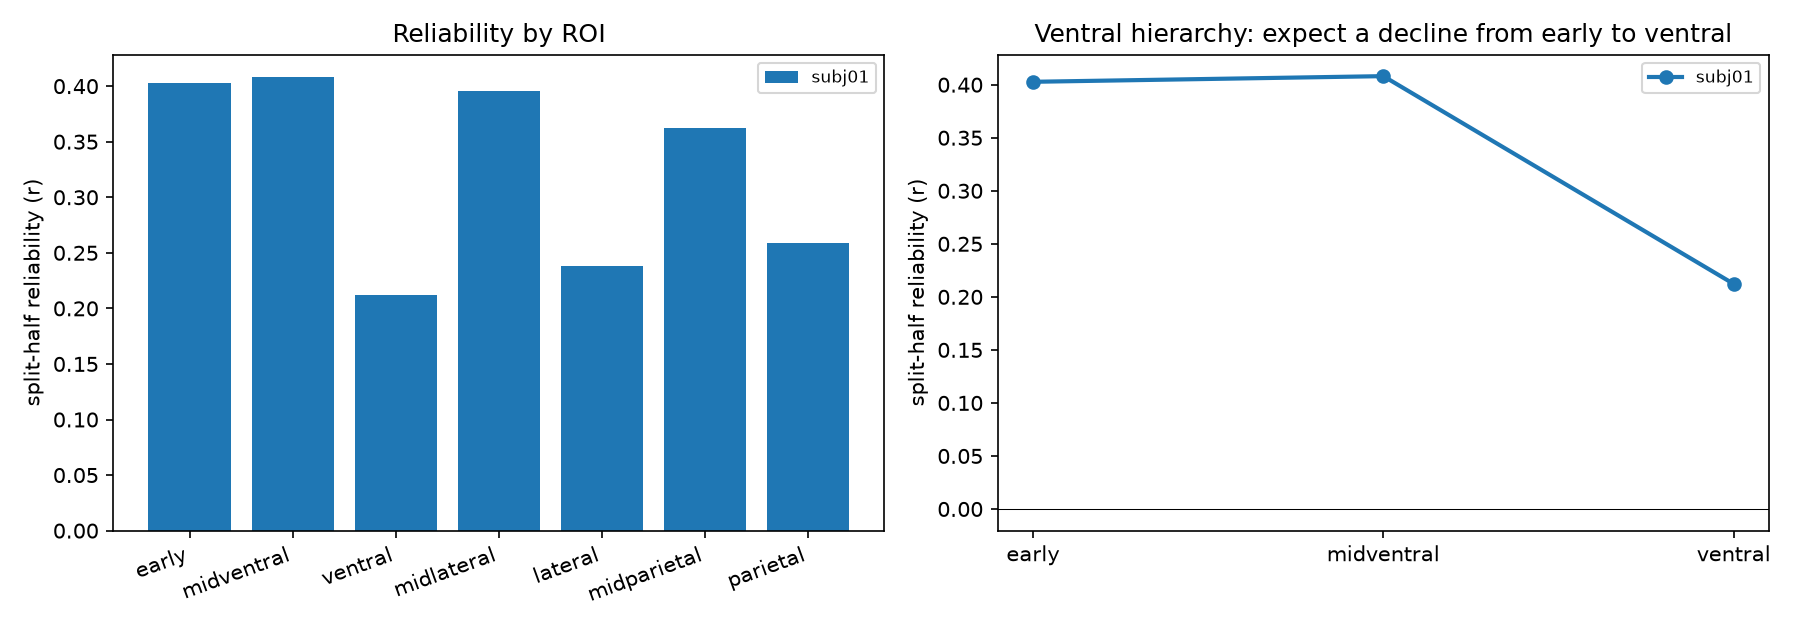

In [3]:
IMG("s1_split_half_reliability.png", 900)   # scripts/s1_sanity_checks.py

## 2. Часть А — зрительные энкодеры (валидация + бэйзлайны)

Пять моделей с разными целями обучения. Все 35 сочетаний модель×зона значимы. Наивная
гипотеза «self-supervised ближе к мозгу» в вентральной коре **не подтвердилась** — и это
прикрыто литературой (Conwell 2024: training diet важнее архитектуры). Один крупный
локализованный эффект: **провал ResNet-50 в вентральной коре** при равенстве в ранней.


In [4]:
best = pd.DataFrame({m: d["best_norm"] for m, d in r["models"].items()},
                    index=r["rois"]).T
best.columns.name = "пик RSA / потолок"
best.style.background_gradient(axis=None, cmap="viridis").format("{:.3f}")

пик RSA / потолок,early,midventral,ventral,midlateral,lateral,midparietal,parietal
dinov2_vitb14,0.335,0.314,0.238,0.291,0.425,0.231,0.275
dinov2_vitl14,0.403,0.339,0.269,0.302,0.394,0.266,0.299
vit_b16,0.308,0.286,0.277,0.278,0.331,0.251,0.218
clip_vitb16,0.425,0.370,0.293,0.305,0.404,0.249,0.255
resnet50,0.303,0.260,0.125,0.189,0.347,0.153,0.108


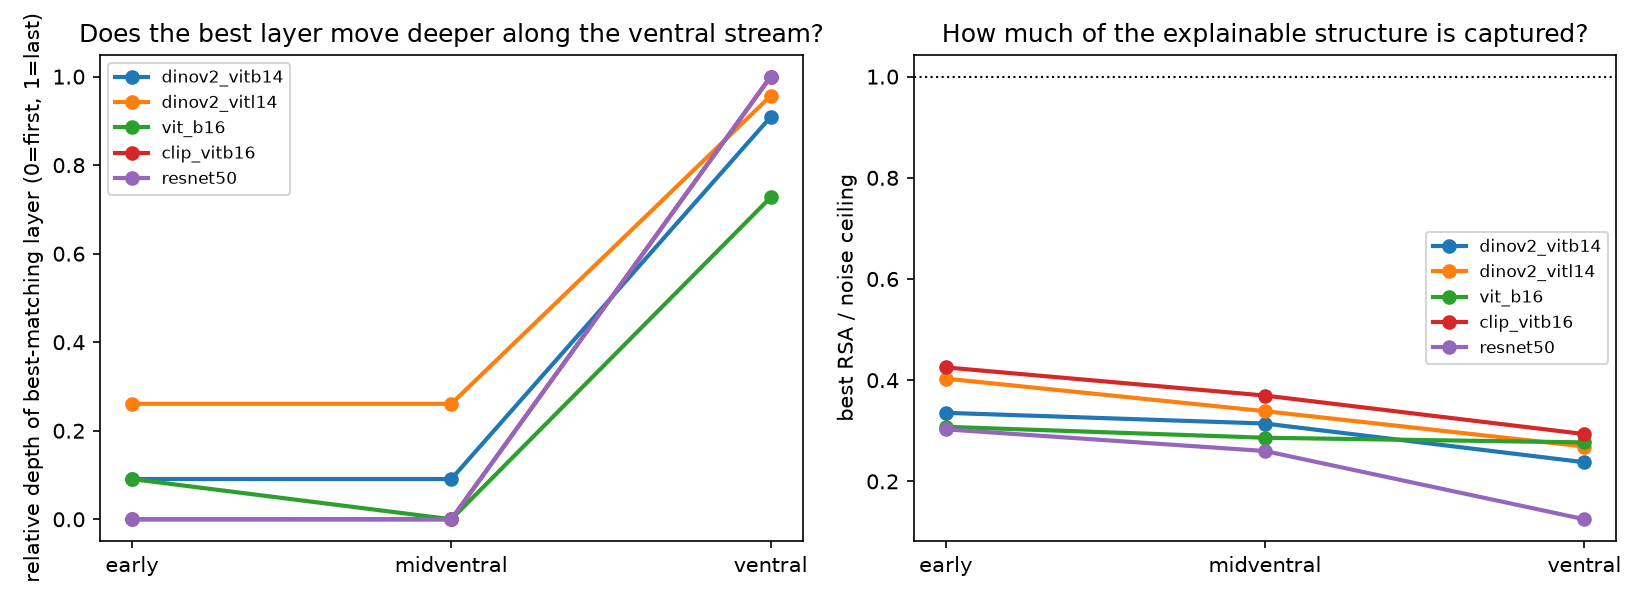

In [5]:
IMG("s3_hierarchy.png", 950)   # scripts/s3_rsa.py — иерархия слои-зоны

## 3. Низкоуровневые контроли: где живёт настоящий сигнал

Любое заявление про соответствие обязано пройти планку тривиальных предикторов.
Поучительные факты:
- **одно число** (средняя яркость) объясняет 0.218 потолка в ранней коре — половину лучшей модели;
- даже каноническая V1-модель (габоровский банк) яркость не бьёт (0.176), Canny — тем более (0.154);
- **`lateral` неуязвим для всех низкоуровневых предикторов** (≤0.016 при 0.33–0.48 у
  моделей, маржа 20–26×) — настоящий сигнал живёт именно там.


In [6]:
lc = J("lowlevel_control.json")
ctrl = pd.DataFrame(lc["norm"], index=lc["labels"], columns=lc["rois"])
ctrl.columns.name = "RSA / потолок"
ctrl.style.background_gradient(axis=None, cmap="RdBu_r", vmin=-0.25, vmax=0.25).format("{:.3f}")

RSA / потолок,early,midventral,ventral,midlateral,lateral,midparietal,parietal
pixels_gray,0.046,0.013,0.026,0.058,-0.005,0.053,0.043
mean_luminance,0.218,0.196,0.107,0.131,0.002,0.147,0.112
rms_contrast,0.101,0.109,0.052,0.050,-0.017,0.035,0.029
canny_edges,0.154,0.126,0.022,0.128,-0.054,0.070,0.019
gabor_energy,0.176,0.165,0.076,0.174,0.016,0.162,0.083


## 4. Часть Б — вся ось VLM-стека

Ось глубины: `vision.00 … vision.NN → projector → llm.00 … llm.MM`, ридаут на слоях LLM —
среднее по **позициям визуальных токенов** (trim: без top-1% токенов по норме).

Три решения дизайна, каждое установлено измерением (см. журнал):
1. **fp32 обязателен** — bf16/fp16 сдвигают RDM на порядок измеряемых эффектов (и на MPS, и на CUDA);
2. **вопрос — до картинки** — при причинном внимании иначе визуальные токены не видят
   вопрос побитово (проверяется пре-флайтом для каждого семейства);
3. **тайлинг выключен** — кора видит всё поле зрения сразу.


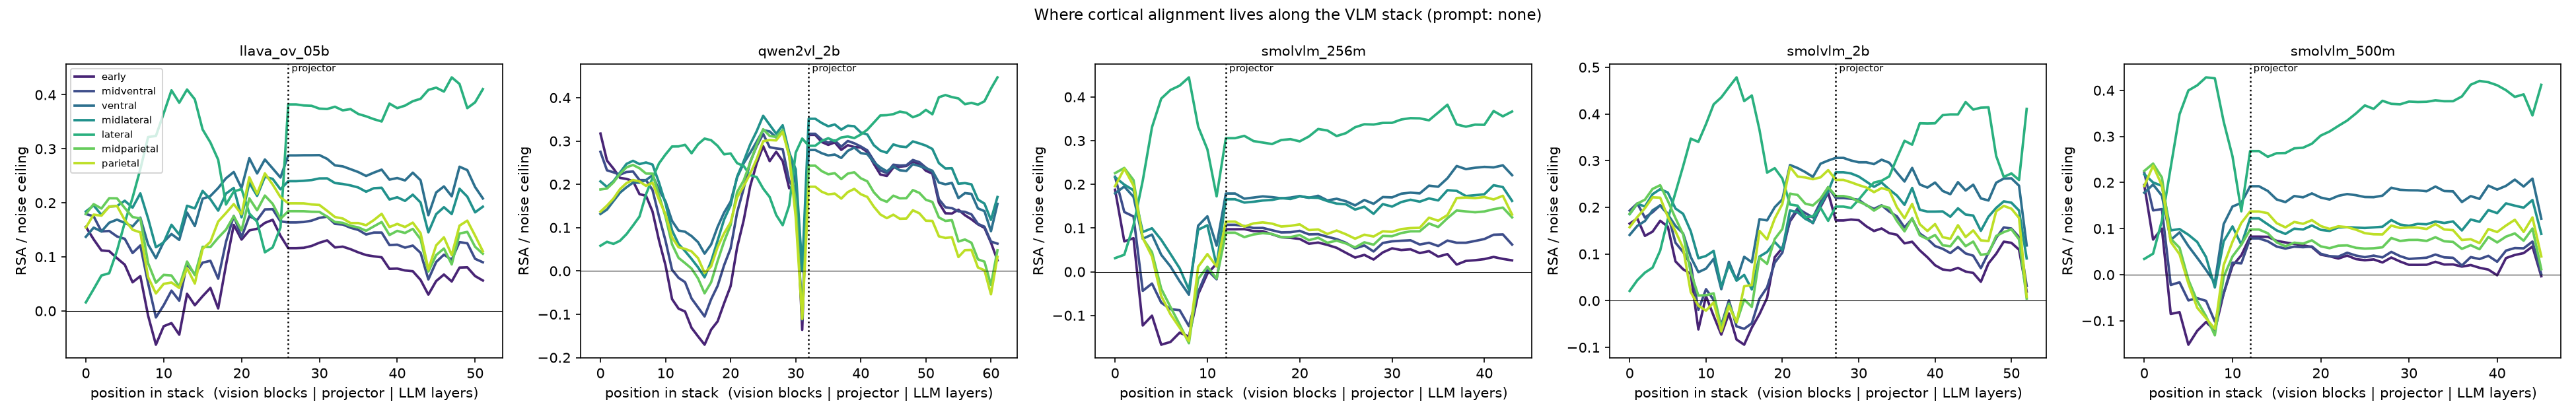

In [7]:
IMG("vlm_stack_profile.png", 1100)   # scripts/vlm_rsa.py

## 5. Главная таблица: наклоны по слоям LLM

Наклон = линейная регрессия (RSA/потолок) по номеру слоя LLM, на каждого испытуемого.
`n/8` — у скольких испытуемых наклон положительный. Wilcoxon по 8 наклонам
(минимально возможное p при n=8 — 0.0078).


In [8]:
from scipy.stats import wilcoxon

f4 = J("f4_summary.json")["slopes_x100"]   # per-subject наклоны, ридаут trim
order = ["smolvlm_256m", "smolvlm_500m", "smolvlm_2b", "qwen2vl_2b", "llava_ov_05b"]
rois = ["early", "midventral", "ventral", "lateral"]
tbl = pd.DataFrame(
    {m: {roi: (lambda v: f"{v.mean():+.2f} · {(v>0).sum()}/8 · p={wilcoxon(v).pvalue:.3f}")
         (np.array(f4[m][roi])) for roi in rois} for m in order}).reindex(rois)
tbl.columns.name = "наклон×100 · рост у · Wilcoxon"
tbl

наклон×100 · рост у · Wilcoxon,smolvlm_256m,smolvlm_500m,smolvlm_2b,qwen2vl_2b,llava_ov_05b
early,-0.22 · 0/8 · p=0.008,-0.13 · 0/8 · p=0.008,-0.43 · 0/8 · p=0.008,-0.90 · 0/8 · p=0.008,-0.30 · 0/8 · p=0.008
midventral,-0.11 · 2/8 · p=0.078,-0.06 · 2/8 · p=0.250,-0.53 · 0/8 · p=0.008,-0.88 · 0/8 · p=0.008,-0.34 · 0/8 · p=0.008
ventral,+0.21 · 7/8 · p=0.023,+0.04 · 3/8 · p=0.742,-0.39 · 0/8 · p=0.008,-0.54 · 0/8 · p=0.008,-0.28 · 0/8 · p=0.008
lateral,+0.22 · 6/8 · p=0.039,+0.53 · 8/8 · p=0.008,+0.61 · 8/8 · p=0.008,+0.47 · 8/8 · p=0.008,+0.16 · 7/8 · p=0.039


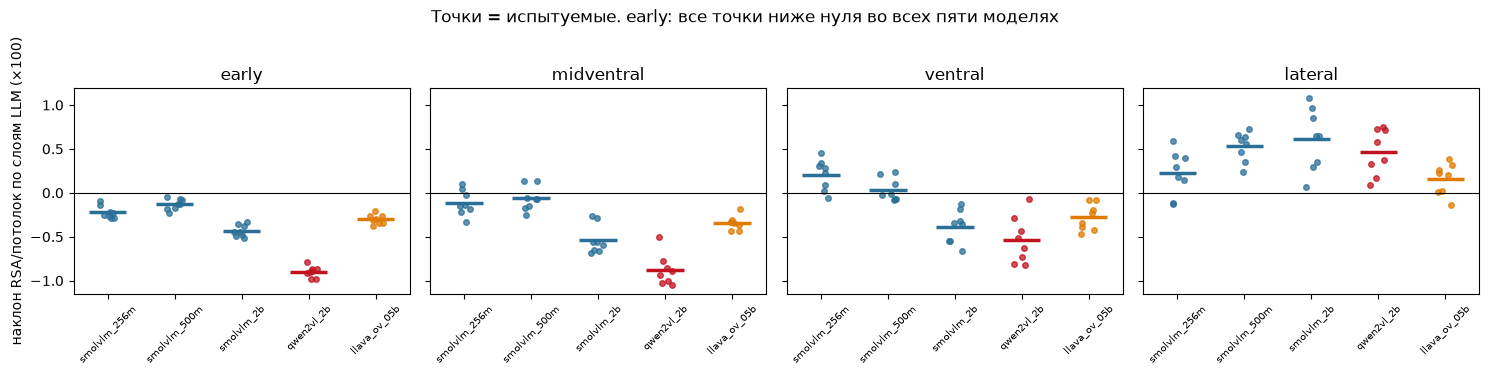

In [9]:
# Та же картина с точками-испытуемыми, построенная из per-subject наклонов
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
rng = np.random.default_rng(0)
for ax, roi in zip(axes, rois):
    for i, m in enumerate(order):
        v = np.array(f4[m][roi])
        c = "#2a6f97" if i < 3 else ("#c1121f" if i == 3 else "#e07a00")
        ax.scatter(i + rng.uniform(-.12, .12, len(v)), v, s=16, color=c, alpha=.75)
        ax.hlines(v.mean(), i - .28, i + .28, color=c, lw=2.5)
    ax.axhline(0, color="k", lw=.8); ax.set_title(roi)
    ax.set_xticks(range(5)); ax.set_xticklabels(order, rotation=45, fontsize=7)
axes[0].set_ylabel("наклон RSA/потолок по слоям LLM (×100)")
fig.suptitle("Точки = испытуемые. early: все точки ниже нуля во всех пяти моделях", y=1.03)
plt.tight_layout(); plt.show()

**Что здесь видно:**
1. **`early` падает у 0/8 испытуемых в каждой из пяти моделей** (p=.008 пять раз) — ядро заявки.
2. **`lateral` растёт** — 6/8→8/8→8/8 внутри SmolVLM, 8/8 у Qwen, 7/8 у LLaVA; единственная
   зона с ростом в межсемейной картине.
3. **`ventral` переворачивает знак с масштабом** внутри SmolVLM (+0.21 → +0.04 → −0.39):
   маленькая модель качественно отличается от большой ⇒ выводы «о мозгоподобности VLM» с
   одной модели не переносятся. В чужих семействах ventral падает (0/8).


## 6. Контроль B9: это не «перечень объектов» (Conwell 2023)

Категорийная RDM (80 категорий COCO, **с учётом кропа** NSD) сама по себе избирательно
латеральна — 0.365 потолка в `lateral`, ≈0 в остальных зонах. После её вычитания
(частичный Спирмен) рост `lateral` выживает у трёх сильных моделей — у 2.2B даже
усиливается (+0.61 → +0.69) — и теряет значимость у двух слабейших. Падение `early`
вычитание не трогает нигде.


In [10]:
b9 = J("f5_b9_categories.json")
rows = []
for m in order:
    for roi in ["early", "lateral"]:
        e = b9[m][roi]
        rows.append({"model": m, "roi": roi,
                     "plain": f"{e['plain']['slope_x100']:+.2f} ({e['plain']['n_positive']}/8, p={e['plain']['p']:.3f})",
                     "partial | категории": f"{e['partial']['slope_x100']:+.2f} ({e['partial']['n_positive']}/8, p={e['partial']['p']:.3f})"})
pd.DataFrame(rows).set_index(["roi", "model"]).sort_index()

plain   partial | категории
roi     model                                                   
early   llava_ov_05b  -0.30 (0/8, p=0.008)  -0.30 (0/8, p=0.008)
        qwen2vl_2b    -0.90 (0/8, p=0.008)  -0.92 (0/8, p=0.008)
        smolvlm_256m  -0.22 (0/8, p=0.008)  -0.22 (0/8, p=0.008)
        smolvlm_2b    -0.43 (0/8, p=0.008)  -0.47 (0/8, p=0.008)
        smolvlm_500m  -0.13 (0/8, p=0.008)  -0.11 (0/8, p=0.008)
lateral llava_ov_05b  +0.16 (7/8, p=0.039)  +0.12 (5/8, p=0.109)
        qwen2vl_2b    +0.47 (8/8, p=0.008)  +0.44 (8/8, p=0.008)
        smolvlm_256m  +0.22 (6/8, p=0.039)  +0.20 (6/8, p=0.148)
        smolvlm_2b    +0.61 (8/8, p=0.008)  +0.69 (8/8, p=0.008)
        smolvlm_500m  +0.53 (8/8, p=0.008)  +0.48 (8/8, p=0.008)

## 7. Контроль B8: деградация или перенацеливание? (Liu 2025)

Линейное декодирование из каждого слоя LLM: **категории объектов декодируются почти
идеально из каждого слоя** (AUC 0.96–0.97, до последнего), а низкоуровневая структура
монотонно тает. Чистая потеря информации предсказала бы совместное падение —
наблюдается избирательное удержание. Языковой стек не портит зрение, он меняет акценты.


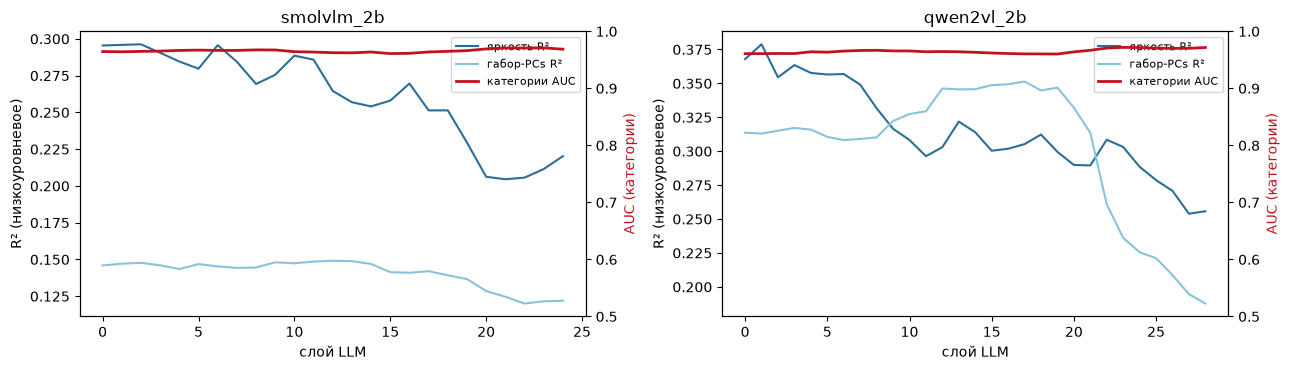

In [11]:
b8 = J("f5_b8_decodability.json")
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, m in zip(axes, ["smolvlm_2b", "qwen2vl_2b"]):
    d = b8[m]; x = np.arange(len(d["layers"]))
    ax2 = ax.twinx()
    ax.plot(x, d["luminance"], label="яркость R²", color="#2a6f97")
    ax.plot(x, d["gabor"], label="габор-PCs R²", color="#89c2d9")
    ax2.plot(x, d["categories_auc"], label="категории AUC", color="#c1121f", lw=2)
    ax2.set_ylim(.5, 1.0); ax.set_title(m); ax.set_xlabel("слой LLM")
    ax.set_ylabel("R² (низкоуровневое)"); ax2.set_ylabel("AUC (категории)", color="#c1121f")
    ln = ax.get_lines() + ax2.get_lines(); ax.legend(ln, [l.get_label() for l in ln], fontsize=8)
plt.tight_layout(); plt.show()

## 8. Второй метод: encoding-модель (B7)

Ridge из каждого слоя LLM в вершины (5-fold CV по картинкам, per-vertex α, R² нормирован
на воксельный потолок из ncsnr).

- **Падение `early` подтверждено**: 0/8 в обеих моделях, p=.008 — ядро заявки метод-независимо.
- **`lateral` в encoding плоский** — и вместе с B8 это уточнение механизма, а не противоречие:
  encoding подбирает линейный ридаут (перевзвешивает признаки), а объектная структура
  линейно доступна в любом слое, поэтому профиль плоский. RSA ничего не перевзвешивает —
  меряет *нативную* геометрию, и вот она дрейфует к латеральной.

**Триангуляция:** низкоуровневое реально удаляется (early падает во всех трёх измерениях);
высокоуровневое всюду линейно присутствует (плоские encoding и AUC); нативная геометрия
прогрессивно организуется вокруг него (рост lateral в RSA). «Приобретают латеральное» —
утверждение о **геометрии**, не об информации.


In [12]:
enc = J("f5_encoding.json")
rows = []
for key, e in enc["slopes"].items():
    m, roi = key.split("|")
    rows.append({"model": m, "roi": roi, "slope×100": e["slope_x100"],
                 "рост у": f"{e['n_positive']}/8", "p": e["p"]})
pd.DataFrame(rows).pivot_table(index="roi", columns="model", values="slope×100",
    ).reindex(["early", "midventral", "ventral", "lateral"]).style.background_gradient(
    axis=None, cmap="RdBu_r", vmin=-.3, vmax=.3).format("{:+.3f}")

model,qwen2vl_2b,smolvlm_2b
roi,,
early,-0.271,-0.065
midventral,-0.228,-0.052
ventral,-0.097,+0.002
lateral,-0.060,-0.005


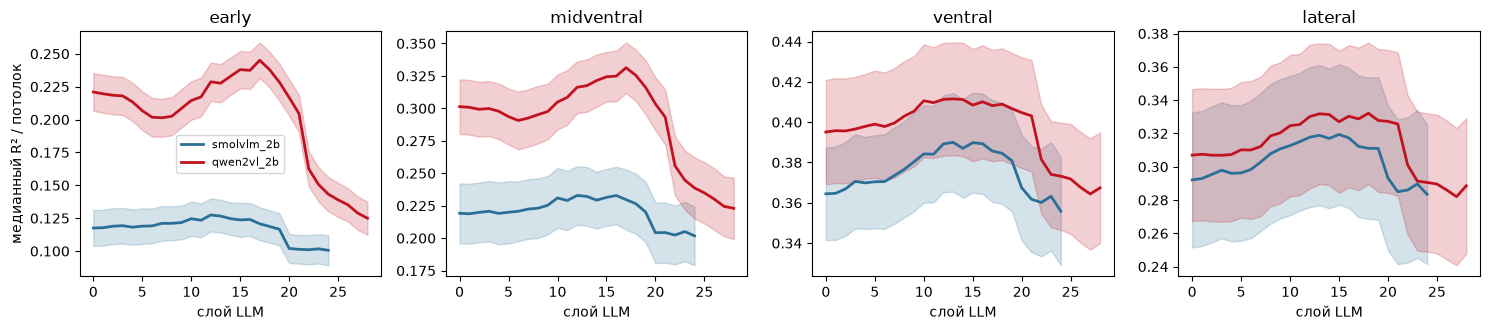

In [13]:
# Профили encoding по глубине, среднее по испытуемым ± SEM
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharex=False)
for ax, roi in zip(axes, rois):
    for m, c in [("smolvlm_2b", "#2a6f97"), ("qwen2vl_2b", "#c1121f")]:
        a = np.asarray(enc["scores"][m][roi]); x = np.arange(a.shape[1])
        ax.plot(x, a.mean(0), color=c, lw=2, label=m)
        ax.fill_between(x, a.mean(0) - a.std(0)/np.sqrt(8), a.mean(0) + a.std(0)/np.sqrt(8),
                        color=c, alpha=.2)
    ax.set_title(roi); ax.set_xlabel("слой LLM")
axes[0].set_ylabel("медианный R² / потолок"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9. Итог: три находки и их статус

| # | Находка | Опора |
|---|---|---|
| 1 | Через языковой стек геометрия дрейфует от ранней коры к латеральному потоку | 0/8 × 5 моделей × 3 семейства; 2 метода; неуязвимость lateral к низкоуровневым предикторам |
| 2 | Механика: низкоуровневое удаляется, высокоуровневое удерживается, нативная геометрия перестраивается | RSA + encoding + декодинг (B8) |
| 3 | Масштаб решает: ventral переворачивает знак с ёмкостью внутри семейства | 3 точки SmolVLM, readout-независимо |

**Ограничения (проговариваем сами):** корреляционный характер; 515 картинок, один датасет;
модели ≤2.2B (fp32-барьер валидности); статические изображения при «динамическом» профиле
латерального потока; сильная версия возражения Conwell (caption-эмбеддинги) — будущая работа.

**Методические вклады:** цена пониженной точности (два бэкенда); позиция промпта при
причинном внимании; токены-выбросы и ридаут trim.

Полная хроника решений — `docs/LAB_JOURNAL.md` · заявка и её границы — `paper/CLAIM.md` ·
драфт — `paper/draft.md`.


---
## 10. Песочница: живые данные для собственного анализа

Ячейка ниже загружает всё, что нужно, чтобы крутить данные руками (~2–3 минуты:
строятся мозговые RDM всех 8 испытуемых). Дальше — готовые примеры.


In [14]:
from nsd_rsa.config import load_config, resolve_paths
from nsd_rsa.design import load_expdesign, usable_images
from nsd_rsa.loaders import average_repeats, common_valid_vertices, load_subject
from nsd_rsa.noise_ceiling import normalise_to_ceiling
from nsd_rsa.rdm import compare_rdms, compute_rdm

cfg = load_config(str(ROOT / "configs" / "vlm.yaml"))
paths = resolve_paths(cfg)
design = load_expdesign(paths["meta"] / "nsd_expdesign.mat")
idx = usable_images(cfg["stimuli"]["subjects"], design, cfg["stimuli"]["min_repeats"])
valid = common_valid_vertices(paths["betas"], paths["cache"] / "valid_vertices.npy")
CEIL = {k: v[0] for k, v in J("rsa_results.json")["ceilings"].items()}

BRAIN = {}   # BRAIN[roi][subject] -> condensed RDM (132 355 пар)
for p in sorted(paths["betas"].glob("*_shared_betas.h5")):
    d = load_subject(p)
    for roi in ["early", "midventral", "ventral", "lateral"]:
        patt, _ = average_repeats(d, images=idx, roi=roi, valid=valid)
        BRAIN.setdefault(roi, {})[d.subject] = compute_rdm(patt.astype(np.float64))
    del d
SUBJECTS = sorted(BRAIN["early"])

ACTS = {m: np.load(ROOT / "cache" / f"f1_readouts_{m}.npz") for m in order}
CATS = np.load(ROOT / "cache" / "coco_categories.npz")   # multihot, area, nsd_ids
IMAGES = np.load(paths["stimuli"] / "shared1000_images.npy", mmap_mode="r")[idx]

print(f"готово: {len(SUBJECTS)} испытуемых · {len(idx)} картинок · модели: {list(ACTS)}")
print("пример ключей активаций:", [k for k in ACTS['qwen2vl_2b'].files[:200]
                                   if k.endswith('.trim')][:4], "...")

готово: 8 испытуемых · 515 картинок · модели: ['smolvlm_256m', 'smolvlm_500m', 'smolvlm_2b', 'qwen2vl_2b', 'llava_ov_05b']
пример ключей активаций: ['vision.00.trim', 'vision.01.trim', 'vision.02.trim', 'vision.03.trim'] ...


In [15]:
def rsa(model, key, roi):
    """RSA/потолок произвольного ридаута против зоны, по испытуемым."""
    rdm = compute_rdm(ACTS[model][key].astype(np.float64))
    return np.array([normalise_to_ceiling(compare_rdms(rdm, BRAIN[roi][s]), CEIL[roi])
                     for s in SUBJECTS])

# пример: последний слой LLM Qwen против lateral и early
for roi in ["lateral", "early"]:
    v = rsa("qwen2vl_2b", "llm.28.trim", roi)
    print(f"qwen2vl_2b llm.28 × {roi:<8} mean={v.mean():.3f}  по испытуемым: {np.round(v, 3)}")

qwen2vl_2b llm.28 × lateral  mean=0.447  по испытуемым: [0.536 0.567 0.526 0.492 0.536 0.309 0.348 0.265]


qwen2vl_2b llm.28 × early    mean=0.025  по испытуемым: [ 0.037 -0.005  0.022  0.032  0.082  0.065 -0.028 -0.002]


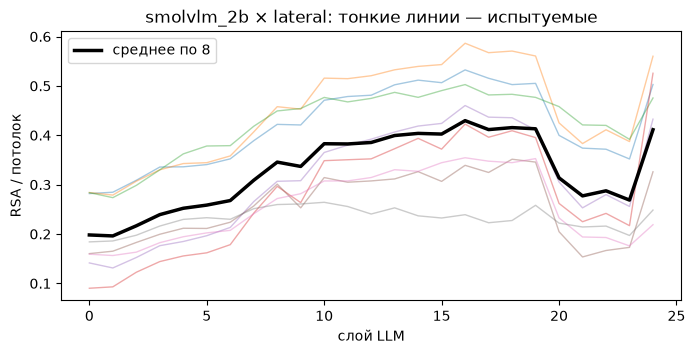

In [16]:
def profile(model, roi, pool="trim"):
    keys = sorted((k for k in ACTS[model].files if k.startswith("llm.") and k.endswith("." + pool)),
                  key=lambda k: int(k.split(".")[1]))
    return keys, np.stack([rsa(model, k, roi) for k in keys])   # (слои, испытуемые)

keys, prof = profile("smolvlm_2b", "lateral")
plt.figure(figsize=(8, 3.5))
for si, s in enumerate(SUBJECTS):
    plt.plot(prof[:, si], alpha=.4, lw=1)
plt.plot(prof.mean(1), "k", lw=2.5, label="среднее по 8")
plt.xlabel("слой LLM"); plt.ylabel("RSA / потолок")
plt.title("smolvlm_2b × lateral: тонкие линии — испытуемые"); plt.legend(); plt.show()

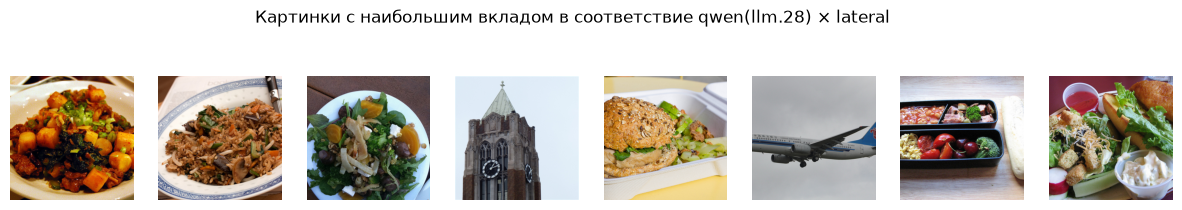

In [17]:
# Какие картинки самые «латеральные»? Вклад картинки в соответствие последнего слоя
# (сумма рангового произведения по парам с участием картинки) — грубая, но наглядная мера.
from scipy.spatial.distance import squareform
from scipy.stats import rankdata

m_rdm = squareform(rankdata(compute_rdm(ACTS["qwen2vl_2b"]["llm.28.trim"].astype(np.float64))))
b_rdm = squareform(rankdata(np.mean([BRAIN["lateral"][s] for s in SUBJECTS], axis=0)))
contrib = ((m_rdm - m_rdm.mean()) * (b_rdm - b_rdm.mean())).sum(1)
top = np.argsort(contrib)[::-1][:8]
fig, axes = plt.subplots(1, 8, figsize=(15, 2.2))
for ax, i in zip(axes, top):
    ax.imshow(IMAGES[i]); ax.axis("off")
fig.suptitle("Картинки с наибольшим вкладом в соответствие qwen(llm.28) × lateral", y=1.08)
plt.show()

**Идеи, что покрутить дальше** (готовые ингредиенты уже в памяти):
- `rsa(model, key, roi)` для любых `vision.*/llm.*` × `mean/trim/median` × 4 зоны;
- `CATS["multihot"]` — присутствие 80 категорий COCO на картинку: например, отфильтровать
  картинки с людьми (`person` — колонка 0) и посмотреть, держится ли рост lateral без них
  (прямой тест предсказания из Discussion);
- `profile(...)` для любой модели/зоны — per-subject кривые;
- сравнить `imgmean` из `cache/vlm_activations/*.h5` между промптами (модуляция задачей).
